In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from models import DataProcessor, Evaluation, RandomForestModel, XGBoostModel


In [2]:
filePath = "/Users/pritibhunia/repos/medium-voltage-cable/Real Data/TD_complete_updated_20241219.csv"
data = pd.read_csv(filePath, delimiter=';')
data.dropna(inplace=True)
print(data.head())


   cable_id  meas_id cable_type_group        date      time  step_id  line_nr  \
0         2      132     Papier-Masse  2021-04-29  09:42:37     2099        1   
1         2      132     Papier-Masse  2021-04-29  09:42:37     2100        1   
2         2      132     Papier-Masse  2021-04-29  09:42:37     2101        1   
3         2      132     Papier-Masse  2021-04-29  09:42:37     2102        1   
4         2      132     Papier-Masse  2021-04-29  09:42:37     2103        2   

   voltage_step_factor    MTD    STD  ...  Skirt Type MTD@1.0   DTD  \
0                  0.5  3.950  0.050  ...  Increasing   4.583  2.65   
1                  1.0  4.583  0.037  ...  Increasing   4.583  2.65   
2                  1.5  6.600  0.082  ...  Increasing   4.583  2.65   
3                  2.0  9.750  0.050  ...  Increasing   4.583  2.65   
4                  0.5  4.333  0.047  ...  Increasing   5.117  2.55   

   Line Deviation category_mtd category_dtd category_std  \
0            2.21         

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2763 entries, 0 to 2781
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   cable_id                      2763 non-null   int64  
 1   meas_id                       2763 non-null   int64  
 2   cable_type_group              2763 non-null   object 
 3   date                          2763 non-null   object 
 4   time                          2763 non-null   object 
 5   step_id                       2763 non-null   int64  
 6   line_nr                       2763 non-null   int64  
 7   voltage_step_factor           2763 non-null   float64
 8   MTD                           2763 non-null   float64
 9   STD                           2763 non-null   float64
 10  Skirt                         2763 non-null   float64
 11  Skirt Type                    2763 non-null   object 
 12  MTD@1.0                       2763 non-null   float64
 13  DTD     

In [4]:
data

,cable_id,meas_id,cable_type_group,date,time,step_id,line_nr,voltage_step_factor,MTD,STD,...,Skirt Type,MTD@1.0,DTD,Line Deviation,category_mtd,category_dtd,category_std,category_line_deviation,additional_skirt_information,category_final
0,2,132,Papier-Masse,2021-04-29,09:42:37,2099,1,0.5,3.950,0.050,...,Increasing,4.583,2.650,2.21,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
1,2,132,Papier-Masse,2021-04-29,09:42:37,2100,1,1.0,4.583,0.037,...,Increasing,4.583,2.650,2.4,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
2,2,132,Papier-Masse,2021-04-29,09:42:37,2101,1,1.5,6.600,0.082,...,Increasing,4.583,2.650,2.13,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
3,2,132,Papier-Masse,2021-04-29,09:42:37,2102,1,2.0,9.750,0.050,...,Increasing,4.583,2.650,2.02,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
4,2,132,Papier-Masse,2021-04-29,09:42:37,2103,2,0.5,4.333,0.047,...,Increasing,5.117,2.550,2.01,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,175,212,Mischkabel,2022-11-16,12:59:05,3862,3,0.8,0.021,0.029,...,Decreasing,0.164,0.148,Not given,1,1,1,Not given,Ansatzweise Feuchtigkeit,1
2778,175,212,Mischkabel,2022-11-16,12:59:05,3863,3,1.0,0.164,0.196,...,Decreasing,0.164,0.148,Not given,1,1,1,Not given,Ansatzweise Feuchtigkeit,1
2779,175,212,Mischkabel,2022-11-16,12:59:05,3864,3,1.3,0.083,0.108,...,Decreasing,0.164,0.148,2.52,1,1,1,3,Ansatzweise Feuchtigkeit,3
2780,175,212,Mischkabel,2022-11-16,12:59:05,3865,3,1.5,0.154,0.130,...,Increasing,0.164,0.148,5.31,1,1,1,4,Leichte water tree Alterung,4


In [5]:
target_column = 'category_final'

In [ ]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns

# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'cable_type_group' column:
['Papier-Masse' 'Mischkabel' 'XLPE']
------------------------------
Distinct values in 'date' column:
['2021-04-29' '2021-04-27' '2021-04-28' '2023-04-20' '2019-10-10'
 '2019-10-11' '2022-09-13' '2021-09-28' '2021-10-21' '2021-10-14'
 '2021-10-05' '2021-10-04' '2021-11-01' '2021-09-23' '2021-10-06'
 '2021-09-30' '2021-11-22' '2021-09-13' '2021-09-20' '2021-12-08'
 '2021-10-07' '2021-10-12' '2021-10-19' '2021-10-18' '2021-10-20'
 '2021-10-13' '2021-10-11' '2021-09-21' '2021-09-08' '2021-09-16'
 '2021-06-10' '2021-09-14' '2021-11-25' '2021-09-07' '2021-09-09'
 '2021-12-07' '2022-09-10' '2022-09-12' '2021-09-27' '2021-09-06'
 '2022-11-14' '2022-11-17' '2023-04-18' '2023-04-19' '2022-11-15'
 '2022-12-14' '2022-11-16' '2022-12-12' '2022-12-13' '2022-12-15'
 '2023-04-17' '2022-11-18']
------------------------------
Distinct values in 'time' column:
['09:42:37' '10:04:43' '15:23:37' '15:18:34' '13:58:51' '14:05:00'
 '11:39:48' '09:09:39' '15:58:17

In [7]:
data.isnull().sum()

cable_id                        0
meas_id                         0
cable_type_group                0
date                            0
time                            0
step_id                         0
line_nr                         0
voltage_step_factor             0
MTD                             0
STD                             0
Skirt                           0
Skirt Type                      0
MTD@1.0                         0
DTD                             0
Line Deviation                  0
category_mtd                    0
category_dtd                    0
category_std                    0
category_line_deviation         0
additional_skirt_information    0
category_final                  0
dtype: int64

In [8]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [9]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'cable_type_group' column:
[1 0 2]
------------------------------
Distinct values in 'date' column:
[ 4  2  3 51  0  1 38 17 30 26 20 19 31 15 21 18 32 10 13 35 22 24 28 27
 29 25 23 14  8 12  5 11 33  7  9 34 36 37 16  6 39 42 49 50 40 46 41 44
 45 47 48 43]
------------------------------
Distinct values in 'time' column:
[ 32  44 139 138 125 127  79  19 144 114  77 117  29 137  73 128  94  57
 143  17  58 101 136  25  90  54 145 135  13  26 104  35  24  65  27  87
 113  81  43  22  49  86 119  16  23 121  71  40  33  89  98  46  72 118
  48 103 115  67  75  70  30  93 120 142  61   4 110  18 126  91  97  38
 111 140  62  28  63  76  20  59 106  60  92 124  15 108  51 102  56  21
   9   3  52   0  10  11  50   6  36 123   1  47  39   8  37 131   7  42
  85 134 112  96  82 107  45  64 129  69 100  12  83 105 122  78  84 130
  99 133 116  31 132  55  88  66  68  74 141  14  34  80  53   5  41   2
  95 109]
------------------------------
Distinct values in 'Skirt Type'

                              cable_id   meas_id  cable_type_group      date  \
cable_id                      1.000000  0.717868         -0.244753  0.749244   
meas_id                       0.717868  1.000000         -0.396163  0.609278   
cable_type_group             -0.244753 -0.396163          1.000000 -0.374867   
date                          0.749244  0.609278         -0.374867  1.000000   
time                         -0.074072  0.039957         -0.129317 -0.075692   
step_id                       0.731206  0.964314         -0.443948  0.613406   
line_nr                       0.001822  0.004238         -0.004381  0.009506   
voltage_step_factor          -0.036028  0.004779         -0.007876 -0.031495   
MTD                           0.033615  0.028320          0.016688  0.024852   
STD                           0.018729  0.019770          0.012043  0.014563   
Skirt                        -0.018053 -0.019190         -0.012000 -0.013974   
Skirt Type                   -0.045625 -

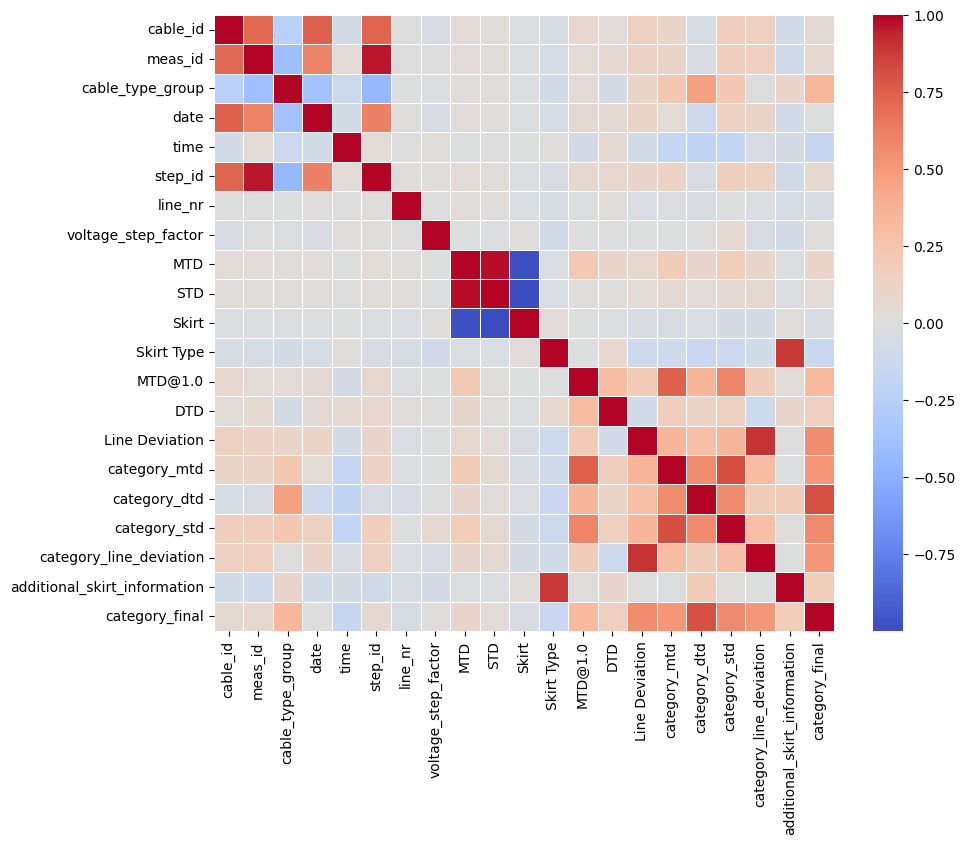

In [10]:
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

                              cable_type_group   line_nr  voltage_step_factor  \
cable_type_group                      1.000000 -0.004381            -0.007876   
line_nr                              -0.004381  1.000000             0.000217   
voltage_step_factor                  -0.007876  0.000217             1.000000   
MTD                                   0.016688  0.021869            -0.000502   
STD                                   0.012043  0.023389            -0.012425   
Skirt                                -0.012000 -0.023515             0.012664   
Skirt Type                           -0.075638 -0.043344            -0.087854   
MTD@1.0                               0.036121 -0.009925            -0.006313   
DTD                                  -0.058648  0.019319             0.001173   
Line Deviation                        0.108320 -0.029287            -0.000909   
additional_skirt_information          0.099717 -0.046615            -0.068590   
category_final              

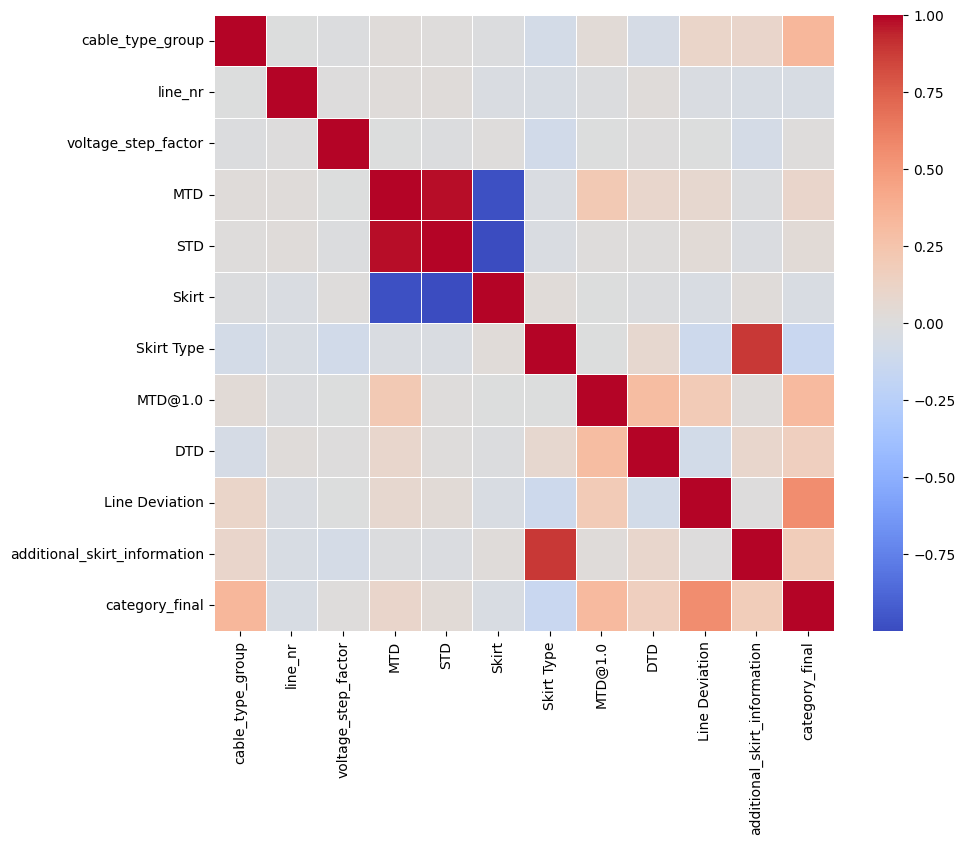

In [11]:
data_for_analysis = data.drop(['cable_id', 'meas_id', 'date', 'time', 'step_id', 'category_mtd', 'category_dtd', 'category_std', 'category_line_deviation'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [12]:
data_for_analysis

,cable_type_group,line_nr,voltage_step_factor,MTD,STD,Skirt,Skirt Type,MTD@1.0,DTD,Line Deviation,additional_skirt_information,category_final
0,1,1,0.5,3.950,0.050,0.02571,2,4.583,2.650,129,7,3
1,1,1,1.0,4.583,0.037,0.01429,2,4.583,2.650,146,7,3
2,1,1,1.5,6.600,0.082,0.02286,2,4.583,2.650,121,7,3
3,1,1,2.0,9.750,0.050,0.00857,2,4.583,2.650,111,7,3
4,1,2,0.5,4.333,0.047,0.02286,2,5.117,2.550,110,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...
2777,0,3,0.8,0.021,0.029,-0.00157,0,0.164,0.148,309,0,1
2778,0,3,1.0,0.164,0.196,-0.04118,0,0.164,0.148,309,0,1
2779,0,3,1.3,0.083,0.108,-0.00808,0,0.164,0.148,155,0,3
2780,0,3,1.5,0.154,0.130,0.04264,2,0.164,0.148,266,4,4


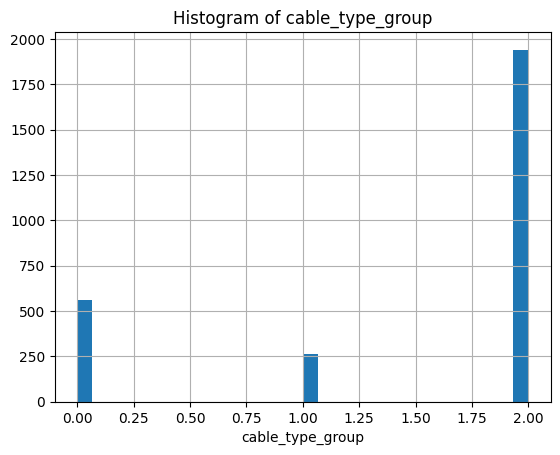

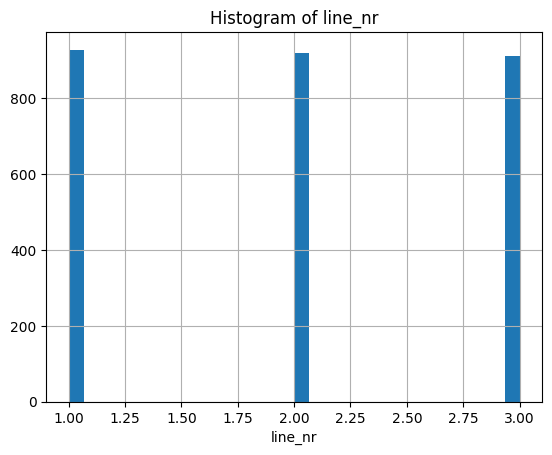

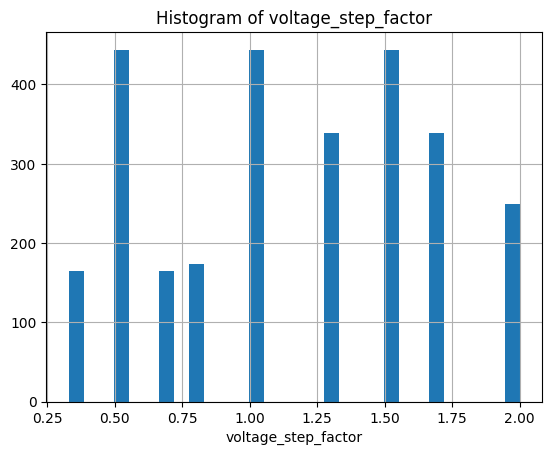

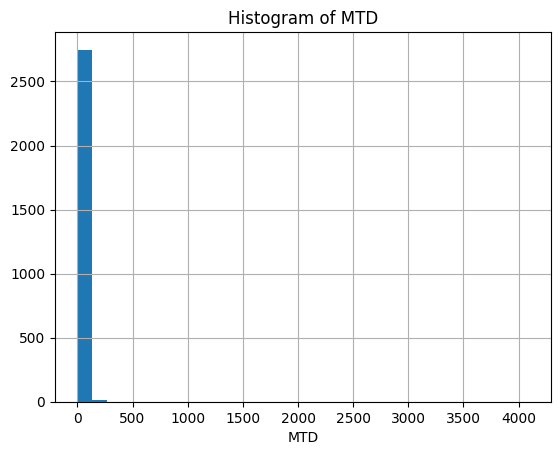

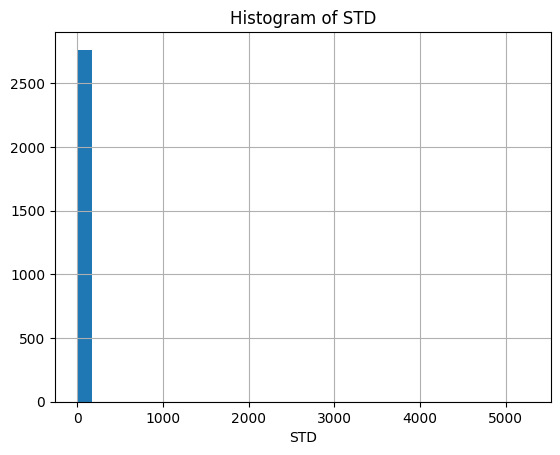

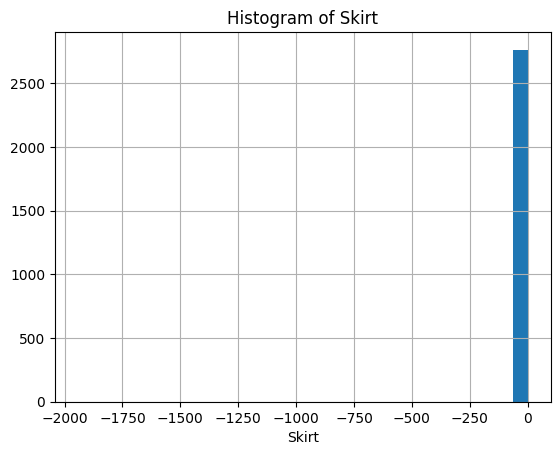

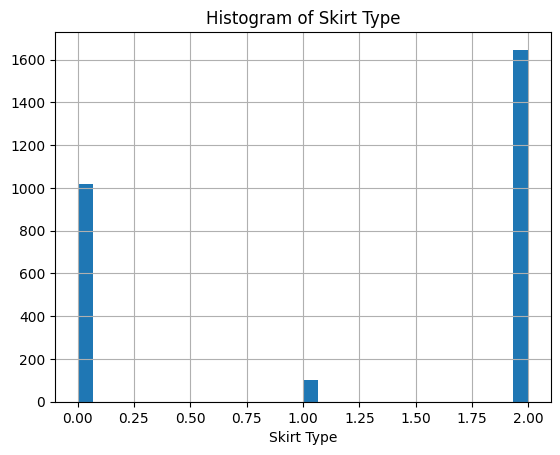

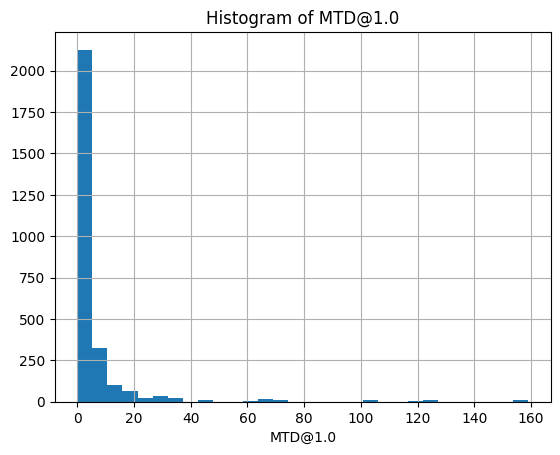

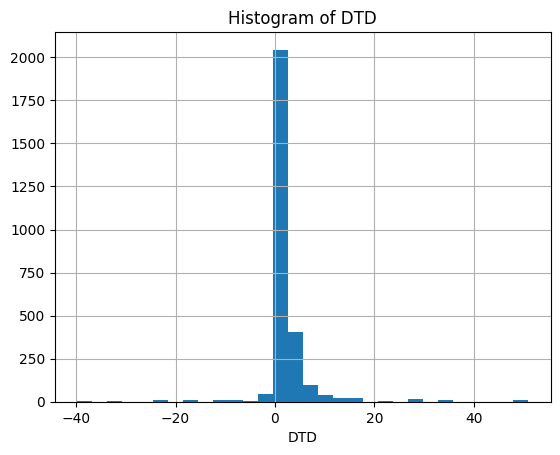

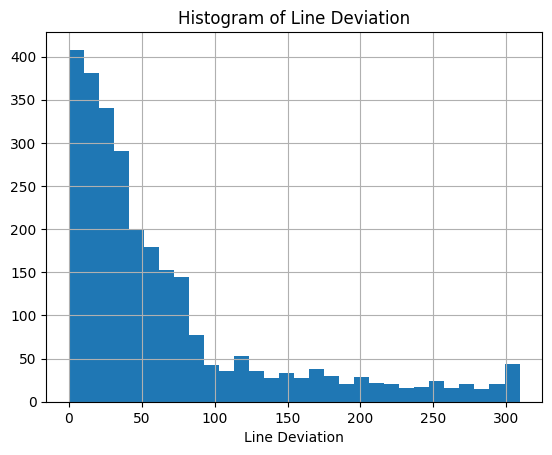

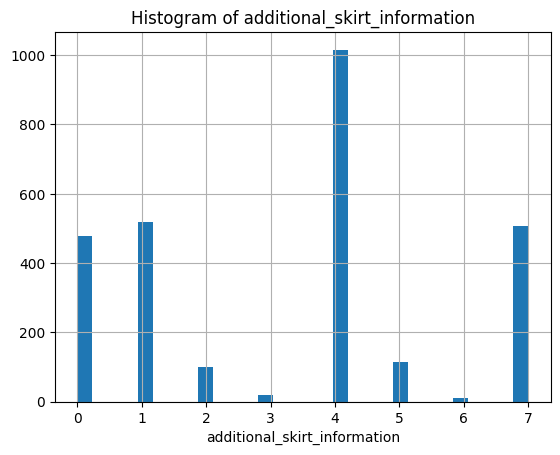

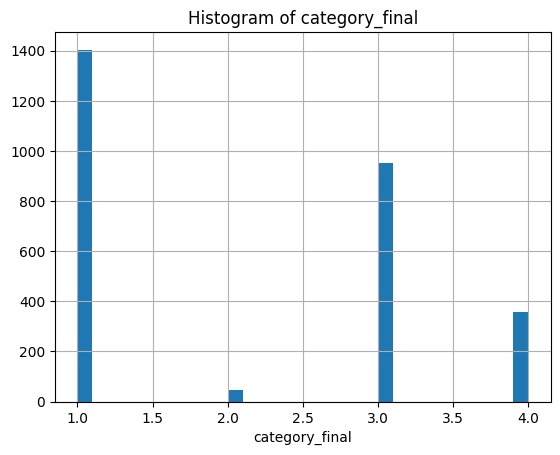

In [13]:
for col in data_for_analysis.columns:
    data_for_analysis[col].hist(bins=30)
    plt.xlabel(col)
    plt.title(f'Histogram of {col}')
    plt.show()

In [14]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

In [15]:
def make_mi_scores(X, y):
    mi_scores = mutual_info_regression(X.values, y.values)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [16]:
mi_scores = make_mi_scores(x, y)

In [17]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    
    plt.figure(dpi=120, figsize=(18, 18))
    bars = plt.barh(width, scores)
    
    plt.yticks(width, ticks)
    plt.xlabel("MI Scores")
    plt.title("Mutual Information Scores")
    
    # Add value annotations to each bar
    for bar in bars:
        plt.gca().text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
                       f'{bar.get_width():.2f}', ha='left', va='center')
    
    plt.show()

<Figure size 2400x2400 with 0 Axes>

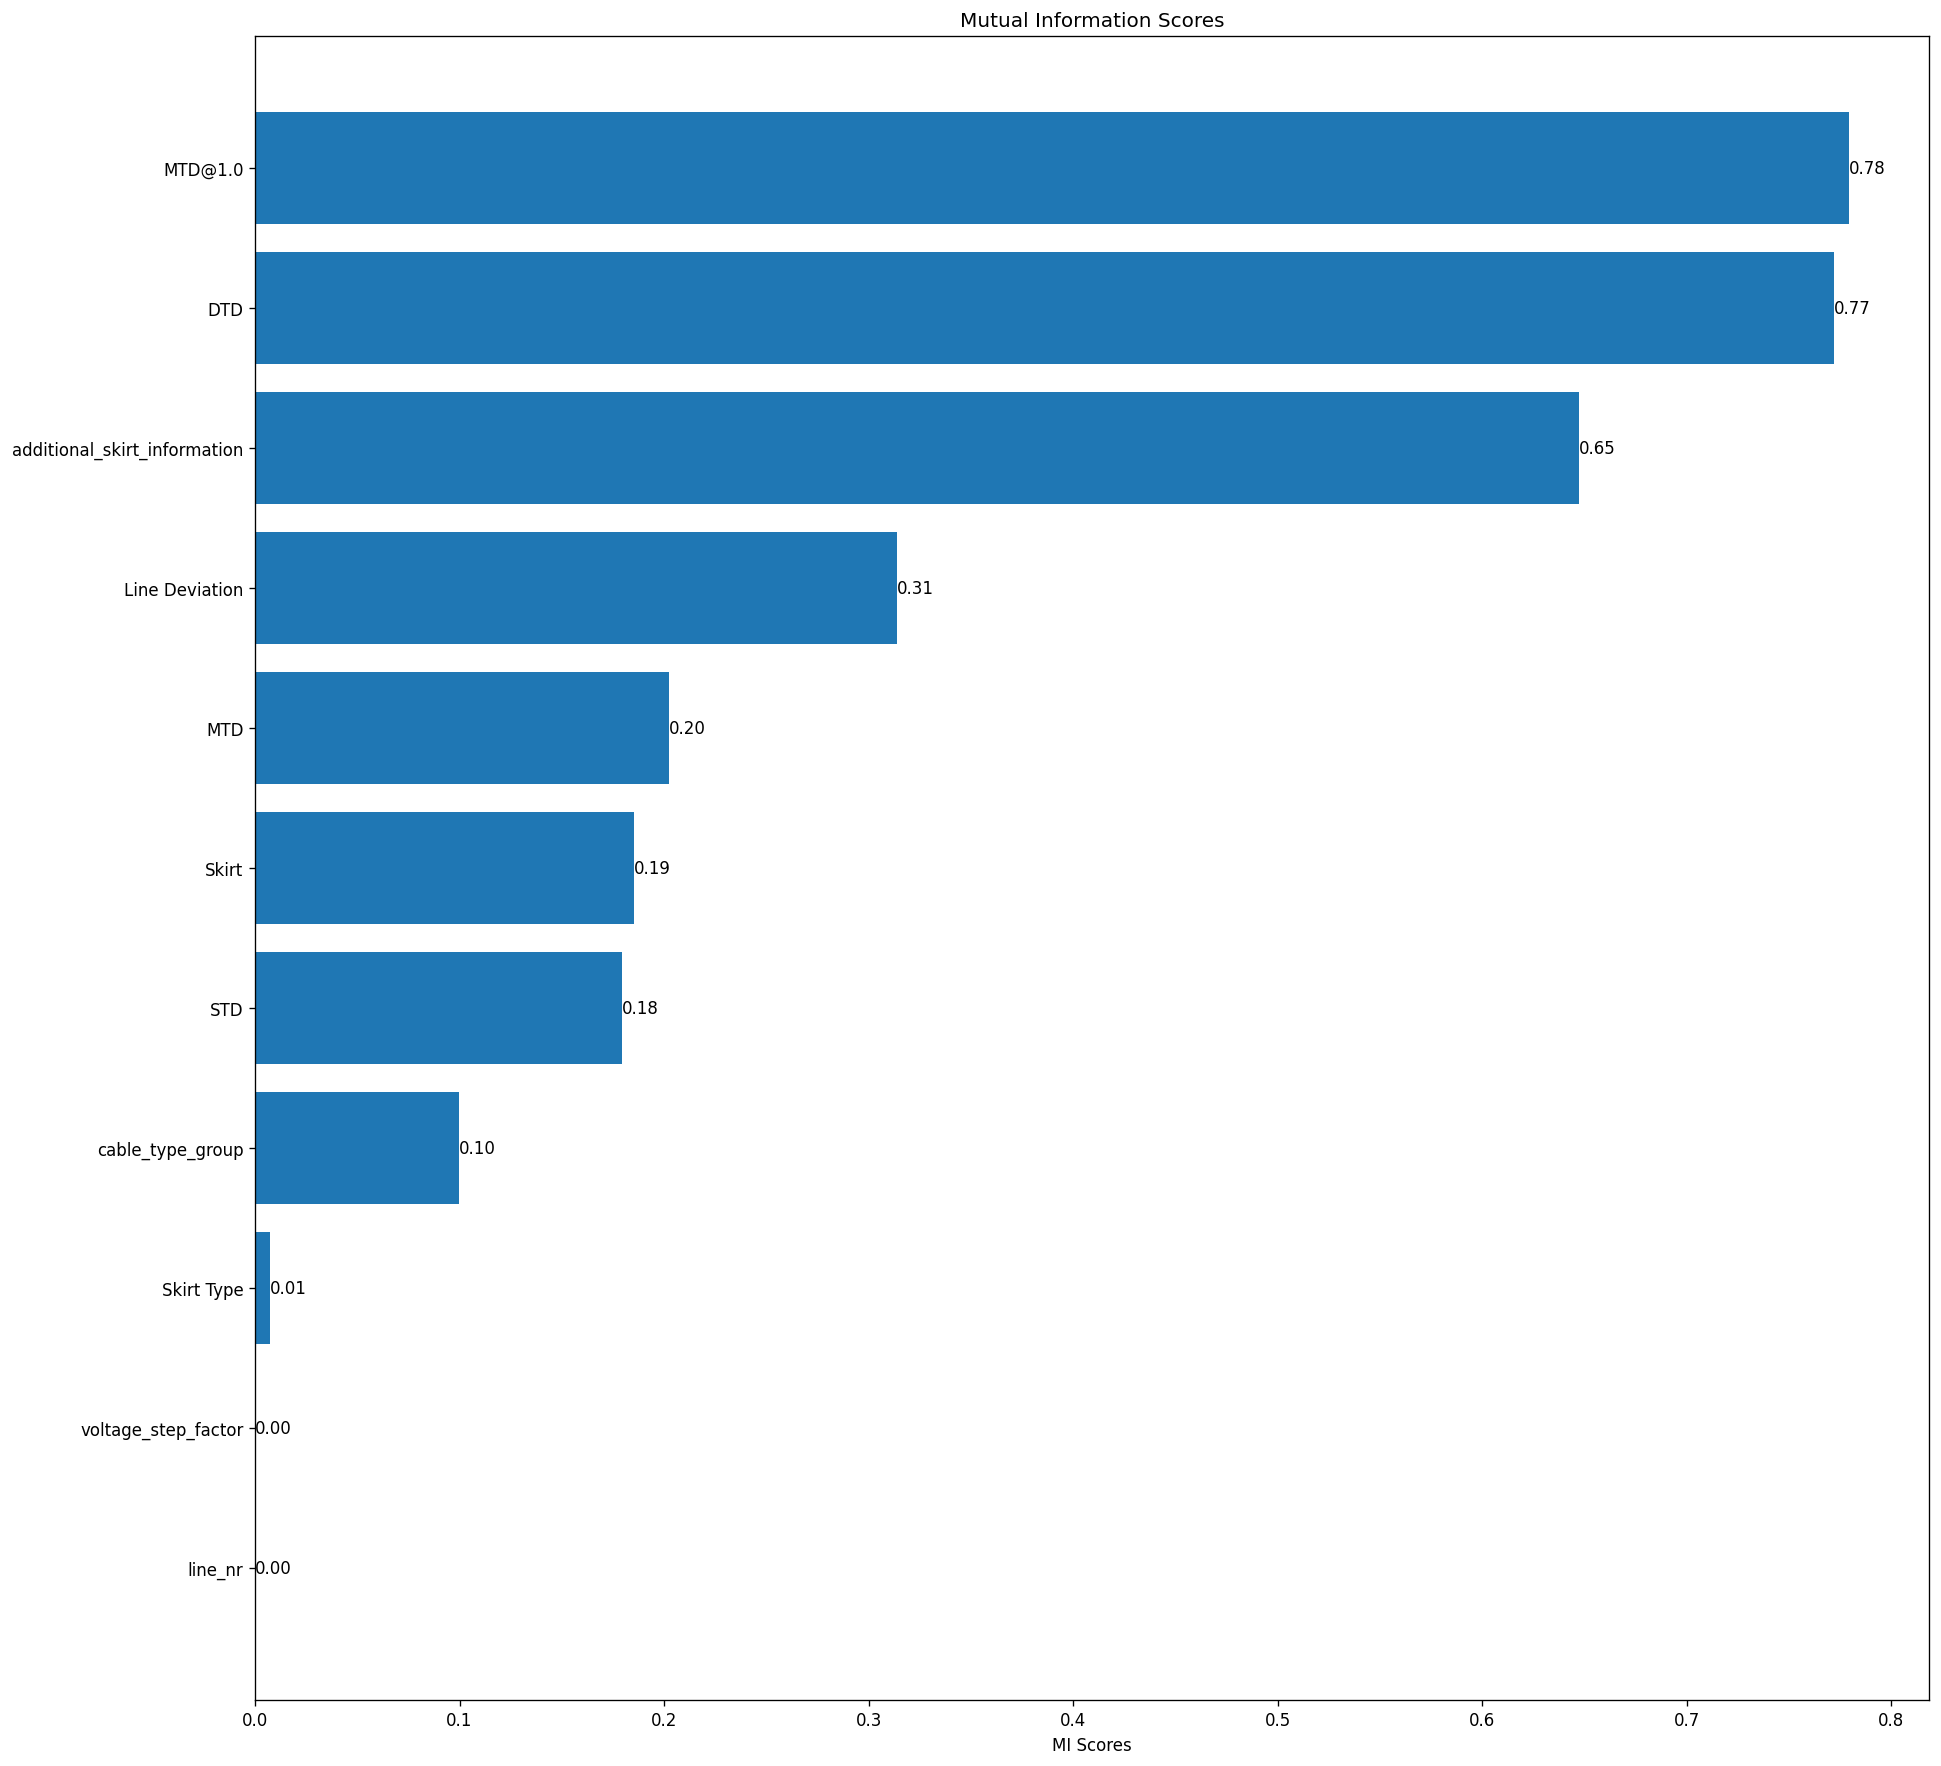

In [18]:
plt.figure(dpi=120, figsize=(20, 20))
plot_mi_scores(mi_scores)

In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Initialize and train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Map feature importance to feature names
feature_importance_df = pd.DataFrame(
    {"feature": x.columns, "importance": feature_importances}
)
feature_importance_df = feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(feature_importance_df)

                         feature  importance
10  additional_skirt_information    0.481677
9                 Line Deviation    0.311347
5                          Skirt    0.112002
0               cable_type_group    0.027476
8                            DTD    0.027408
7                        MTD@1.0    0.017708
4                            STD    0.011032
3                            MTD    0.005757
6                     Skirt Type    0.004487
2            voltage_step_factor    0.000736
1                        line_nr    0.000370


/var/folders/l4/hjg6t7yd399dvgb3tbygj7hr0000gn/T/ipykernel_55524/1957462479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df['importance'], y=feature_importance_df['feature'], palette='viridis')


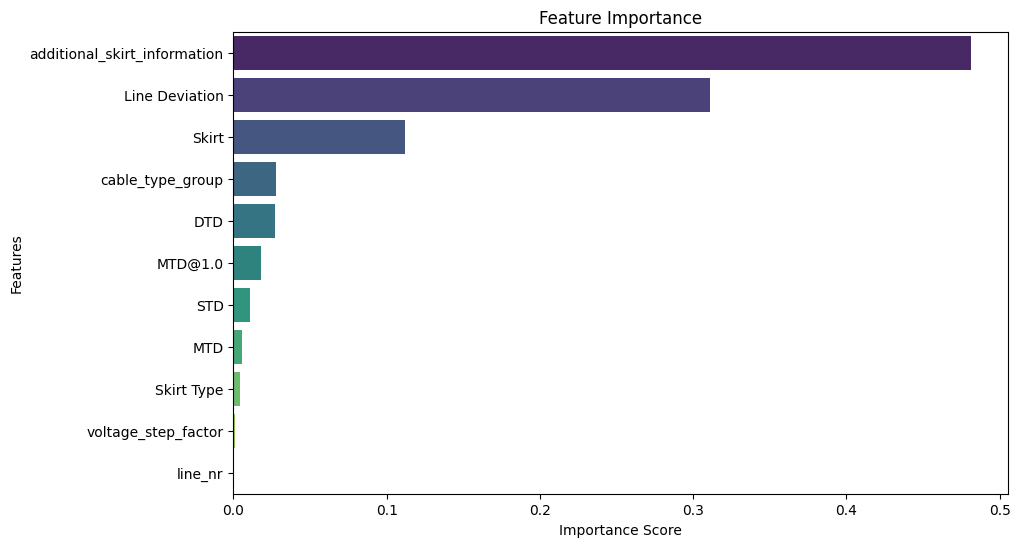

In [20]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['importance'], y=feature_importance_df['feature'], palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

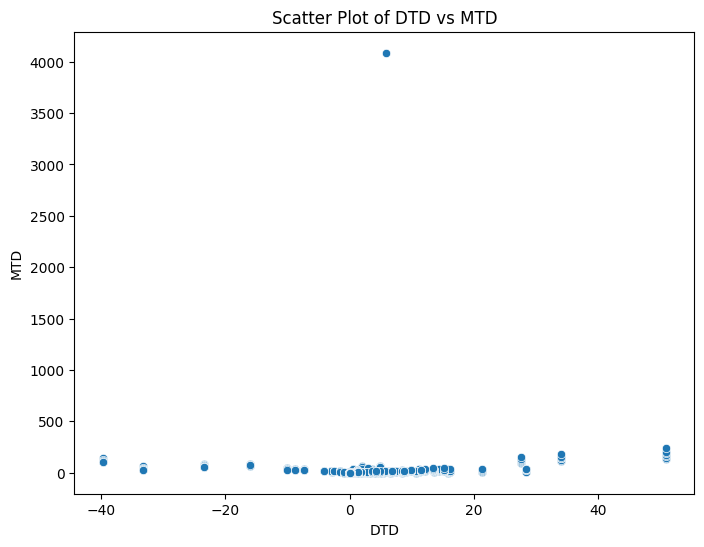

count    2763.000000
mean        8.107188
std        79.436765
min         0.000000
25%         0.872000
50%         1.901000
75%         5.566500
max      4087.844000
Name: MTD, dtype: float64

In [21]:
# Scatter plot
feature1 = 'DTD'
feature2 = 'MTD'
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_for_analysis[feature1], y=data_for_analysis[feature2])
plt.title(f'Scatter Plot of {feature1} vs {feature2}')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.show()
data_for_analysis['MTD'].describe()

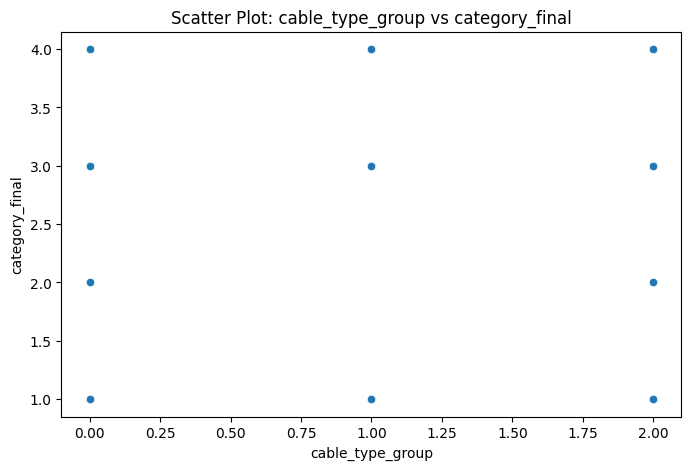

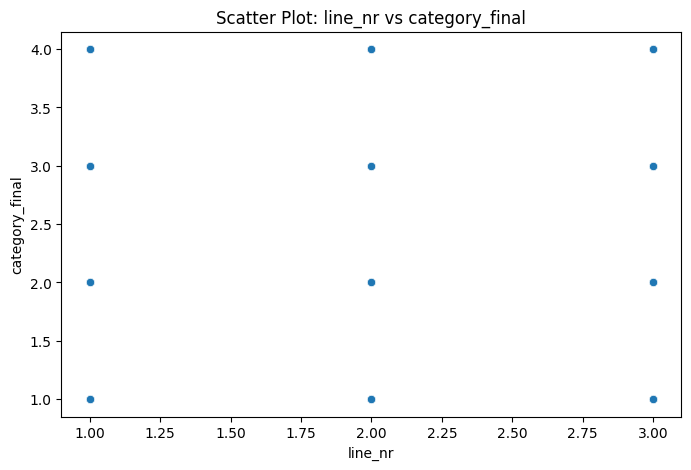

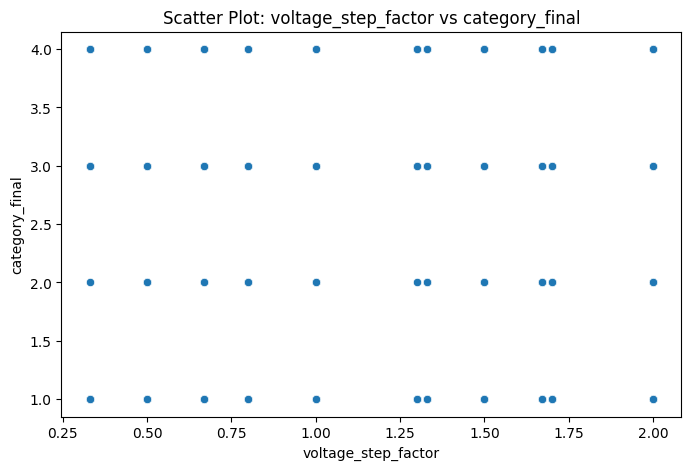

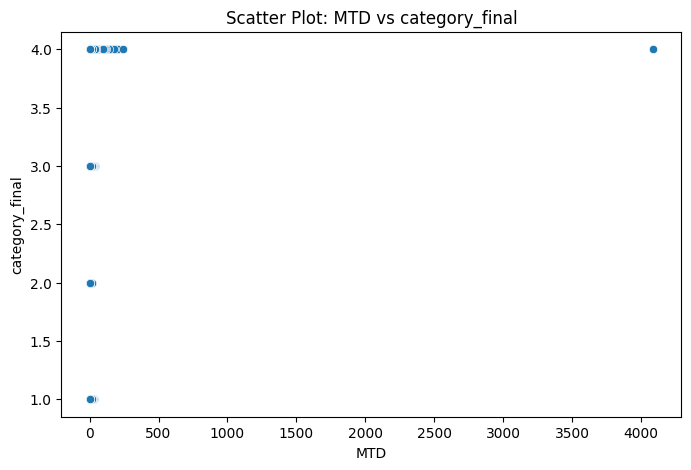

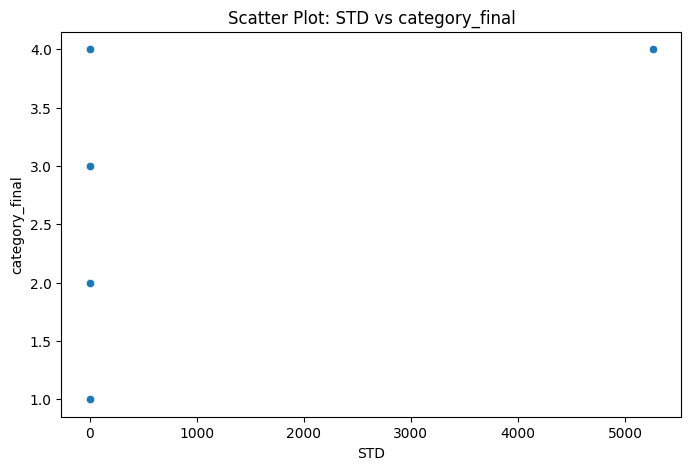

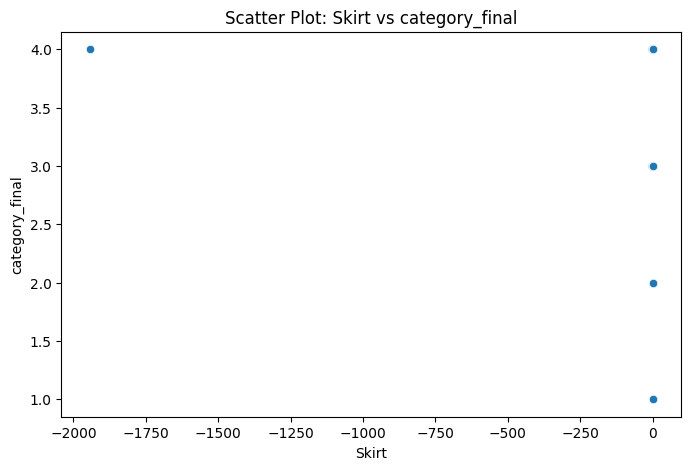

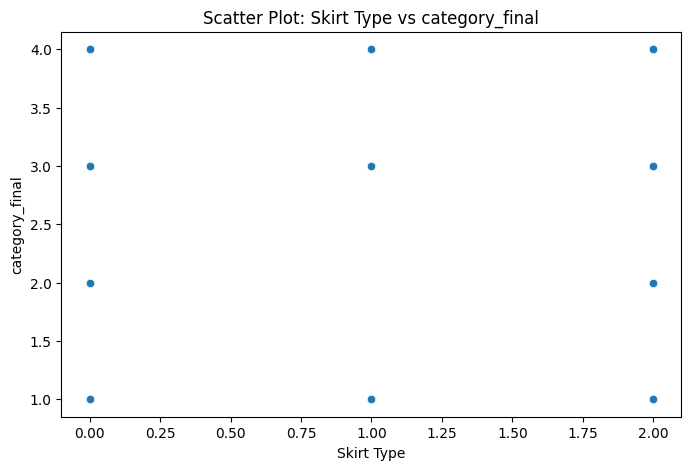

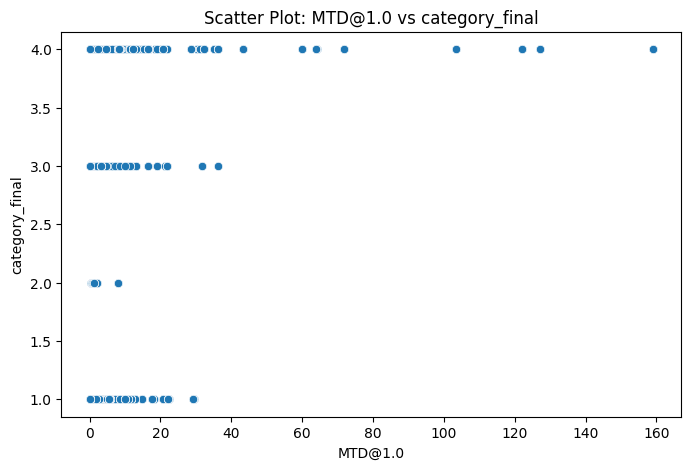

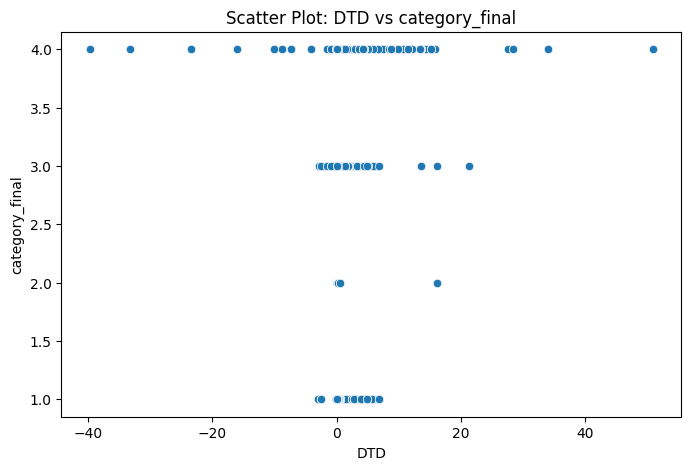

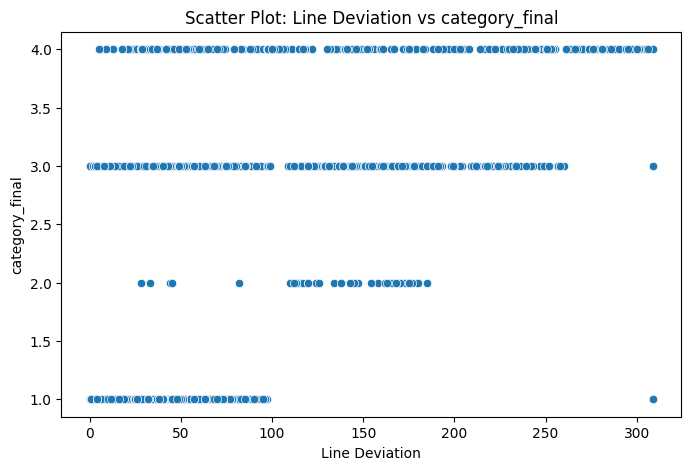

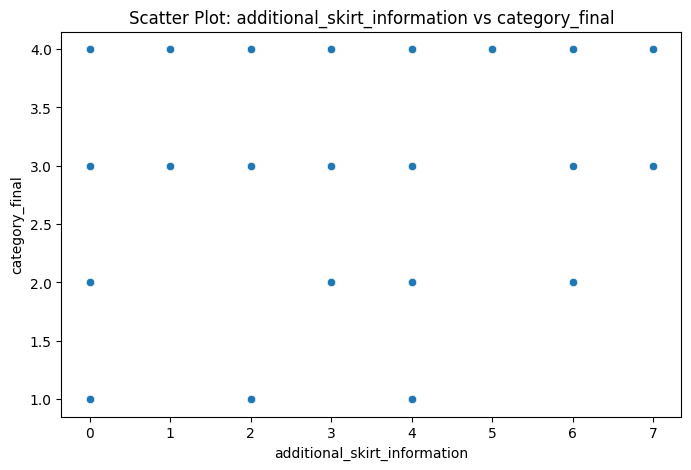

In [22]:
for feature in data_for_analysis.columns:
    if feature != target_column:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=data_for_analysis, x=feature, y=target_column)
        plt.title(f'Scatter Plot: {feature} vs {target_column}')
        plt.show()

In [23]:
# Drop rows where 'MTD' > 4000 and 'STD' > 5000 to remove the extreme condition
data_for_analysis = data_for_analysis[~((data_for_analysis['MTD'] > 4000) & (data_for_analysis['STD'] > 5000))]

In [24]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

# Select numerical features
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns
print("Numerical features:", numerical_features)


# Apply log transformation to all numerical features
# Shift values to make them positive
for feature in numerical_features:
    if feature not in object_cols:
        min_value = x[feature].min()
        if min_value <= 0:
            x[feature] = np.log1p(x[feature] - min_value + 1)
        else:
            x[feature] = np.log1p(x[feature])


# Check the transformed dataframe
x.head()


# List of features that were log-transformed
log_transformed_features = [feature for feature in numerical_features if feature not in object_cols]

# Plot the distribution of each log-transformed feature
for feature in log_transformed_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(x[feature], kde=True)
    plt.title(f'Distribution of {feature} after Log Transformation')
    plt.show()

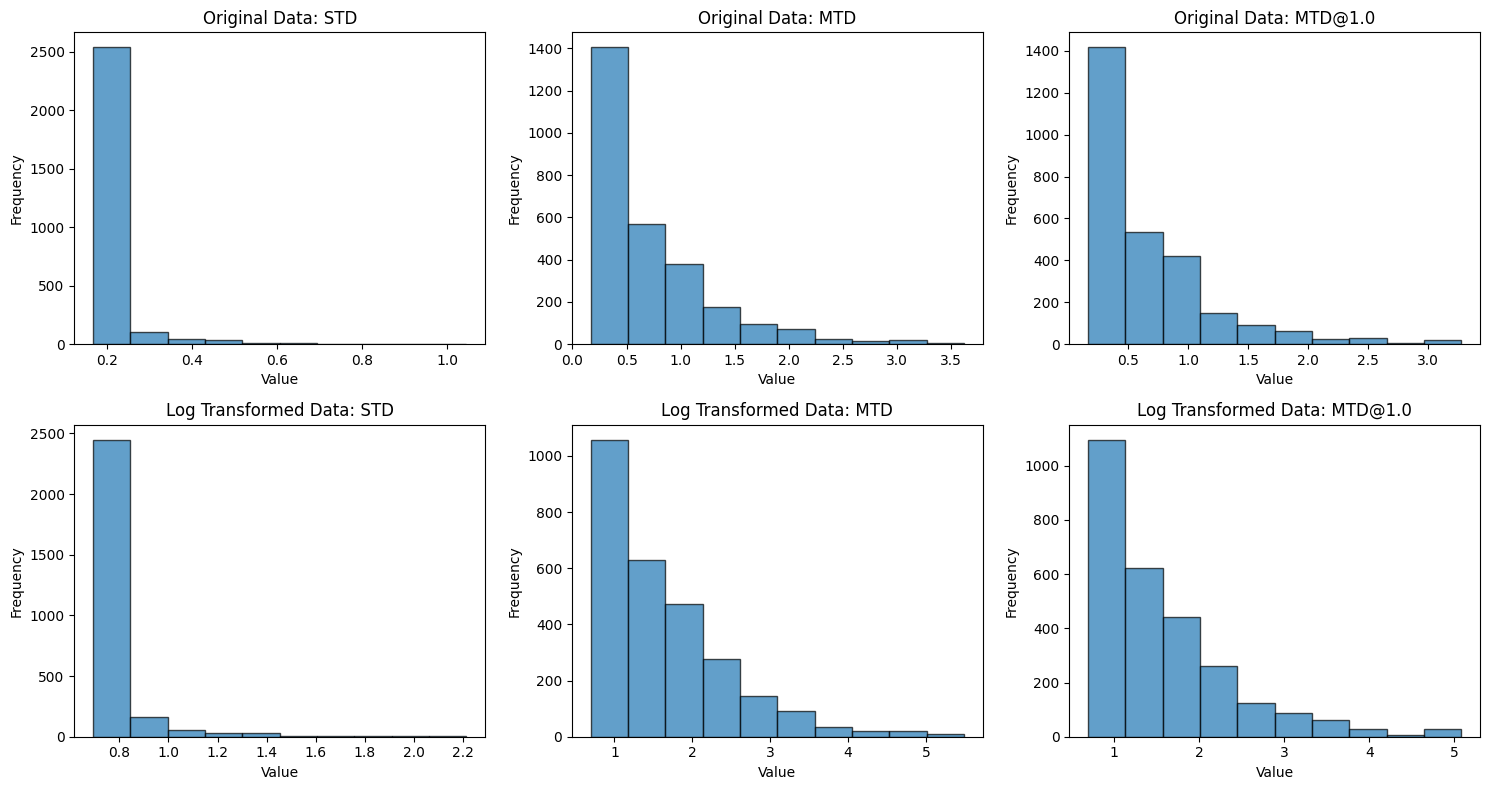

In [25]:
# Define numerical features
numerical_features = ['STD', 'MTD', 'MTD@1.0']

# Define the safe log transform function
def safe_log_transform(series):
    min_value = series.min()
    return np.log1p(series - min_value + 1) if min_value <= 0 else np.log1p(series)

# Apply log transformation with safe_log_transform
data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)

# Plot original vs. transformed data
fig, axes = plt.subplots(2, len(numerical_features), figsize=(15, 8))
titles = ["Original Data", "Log Transformed Data"]

for i, col in enumerate(numerical_features):
    for j, (data, title) in enumerate(zip(
        [data_for_analysis[col] - np.log1p(data_for_analysis[col]), data_for_analysis[col]], titles
    )):
        axes[j, i].hist(data, bins=10, edgecolor='k', alpha=0.7)
        axes[j, i].set_title(f"{title}: {col}")
        axes[j, i].set_xlabel("Value")
        axes[j, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [26]:
# Standard deviation before scaling
x.std()

cable_type_group                 0.808883
line_nr                          0.816547
voltage_step_factor              0.506494
MTD                             16.791678
STD                              0.511824
Skirt                            0.180870
Skirt Type                       0.954761
MTD@1.0                         15.674216
DTD                              5.560254
Line Deviation                  72.858060
additional_skirt_information     2.404509
dtype: float64

In [27]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [28]:
# standard deviation after scaling
x_standardized.std()

cable_type_group                1.000181
line_nr                         1.000181
voltage_step_factor             1.000181
MTD                             1.000181
STD                             1.000181
Skirt                           1.000181
Skirt Type                      1.000181
MTD@1.0                         1.000181
DTD                             1.000181
Line Deviation                  1.000181
additional_skirt_information    1.000181
dtype: float64

In [29]:
x_standardized.columns

Index(['cable_type_group', 'line_nr', 'voltage_step_factor', 'MTD', 'STD',
       'Skirt', 'Skirt Type', 'MTD@1.0', 'DTD', 'Line Deviation',
       'additional_skirt_information'],
      dtype='object')

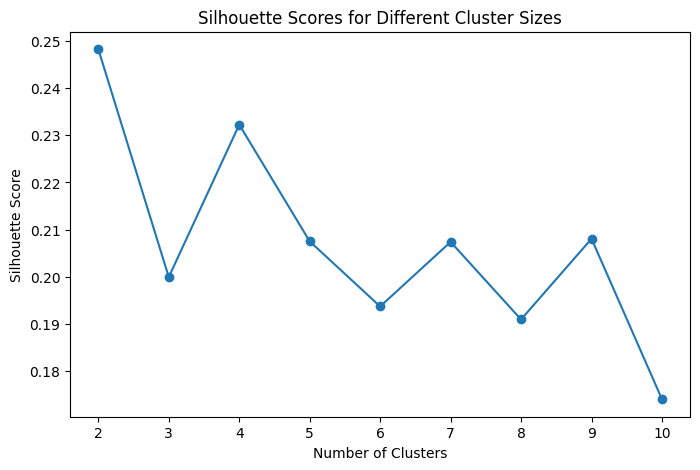

In [30]:
silhouette_scores = []
cluster_range = range(2, 11)

# Loop through cluster sizes
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(x_standardized)
    
    # Check if clustering was successful (i.e., at least 2 clusters)
    if len(set(kmeans_labels)) > 1:
        score = silhouette_score(x_standardized, kmeans_labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)  # If not successful, add a low score

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different Cluster Sizes")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [31]:
# Define number of clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(x_standardized)

/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


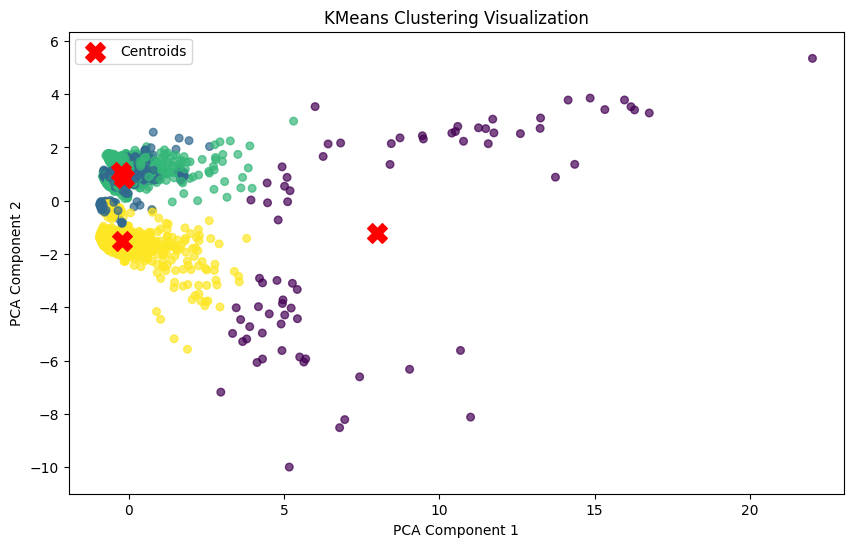

KMeans Silhouette Score: 0.2322


In [32]:
# Apply PCA to reduce features to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_standardized)

# Transform the KMeans centroids using the same PCA transformation
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot the PCA-transformed data points
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("KMeans Clustering Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.xlim(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1)
plt.ylim(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1)
plt.show()

# Evaluate KMeans silhouette score for final clustering
kmeans_silhouette = silhouette_score(x_standardized, kmeans_labels)
print(f"KMeans Silhouette Score: {kmeans_silhouette:.4f}")

#### Gaussian Mixture Models

Best Silhouette Score: 0.2473 with 2 clusters


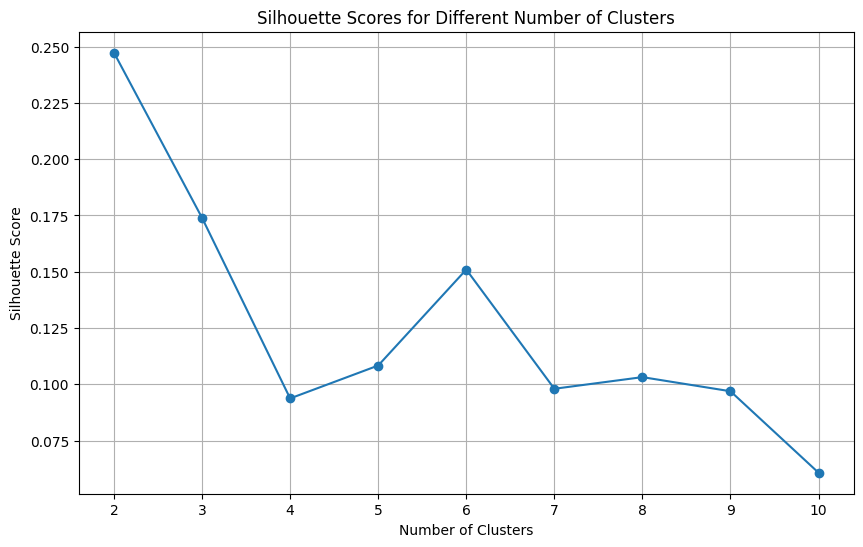

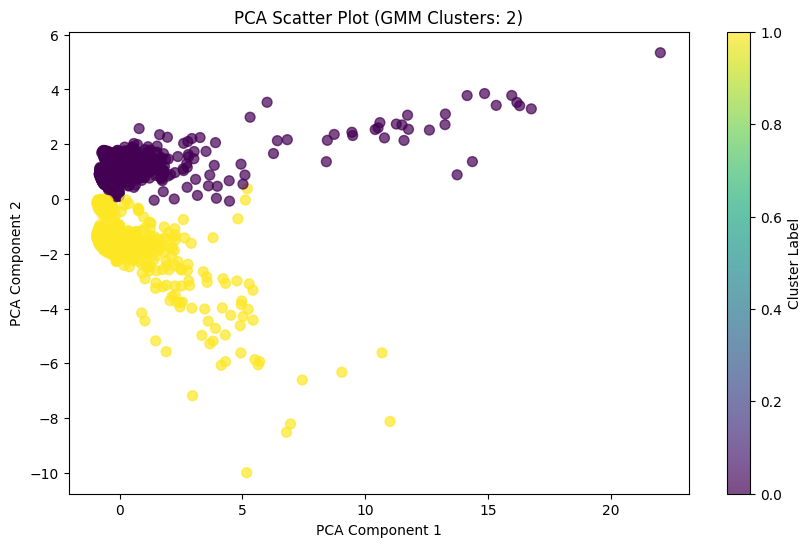

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Function to find the best number of clusters based on silhouette score
def gmm_clustering(X, max_clusters=10):
    best_score = -1
    best_n_clusters = 0
    silhouette_scores = []

    # Test different numbers of clusters
    for n_clusters in range(2, max_clusters + 1):
        gmm = GaussianMixture(n_components=n_clusters, random_state=20)
        labels = gmm.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

        if score > best_score:
            best_score = score
            best_n_clusters = n_clusters

    print(f"Best Silhouette Score: {best_score:.4f} with {best_n_clusters} clusters")

    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
    plt.title("Silhouette Scores for Different Number of Clusters")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    # Return the best model
    best_gmm = GaussianMixture(n_components=best_n_clusters, random_state=20)
    best_gmm.fit(X)
    return best_gmm, best_n_clusters

# Apply the GMM clustering and find the best number of clusters
gmm_model, n_clusters = gmm_clustering(x_standardized)

# Get the labels from the best GMM model
labels = gmm_model.predict(x_standardized)

# Perform PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_standardized)

# Plot the PCA scatter plot with clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title(f"PCA Scatter Plot (GMM Clusters: {n_clusters})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster Label")
plt.show()


### Hierarchical Clustering

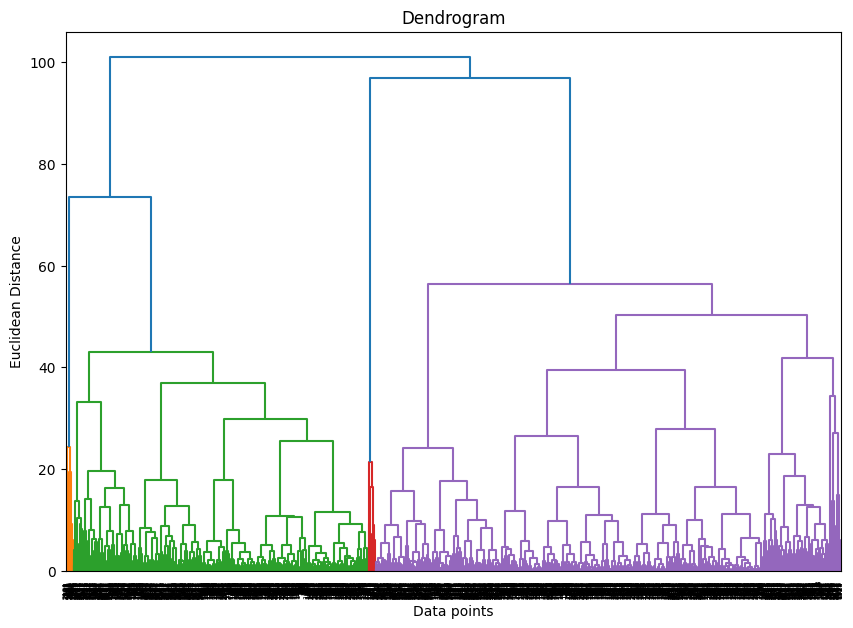

   cable_type_group   line_nr  voltage_step_factor       MTD       STD  \
0         -0.618696 -1.217351            -1.265047 -0.159637 -0.249642   
1         -0.618696 -1.217351            -0.277690 -0.121933 -0.275046   
2         -0.618696 -1.217351             0.709668 -0.001792 -0.187109   
3         -0.618696 -1.217351             1.697025  0.185834 -0.249642   
4         -0.618696  0.007539            -1.265047 -0.136824 -0.255504   

      Skirt  Skirt Type   MTD@1.0       DTD  Line Deviation  \
0  0.148722    0.808246 -0.093489  0.157049        0.853152   
1  0.085571    0.808246 -0.093489  0.157049        1.086524   
2  0.132962    0.808246 -0.093489  0.157049        0.743329   
3  0.053941    0.808246 -0.093489  0.157049        0.606051   
4  0.132962    0.808246 -0.059414  0.139061        0.592323   

   additional_skirt_information  Cluster  
0                      1.554506        0  
1                      1.554506        0  
2                      1.554506        0  
3   

In [34]:
# Step 1: Import required libraries
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Step 2: Create the linkage matrix (using the 'ward' method)
Z = linkage(x_standardized, method='ward')

# Step 3: Plot the Dendrogram to visualize the clusters
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean Distance')
plt.show()

# Step 4: Determine the number of clusters (you can choose this from the Dendrogram)
# For example, let's assume we choose 4 clusters (you can adjust this based on the dendrogram)
optimal_clusters = 4

# Step 5: Perform Hierarchical Clustering with the chosen number of clusters
hc = AgglomerativeClustering(n_clusters=optimal_clusters, linkage='ward')
clusters = hc.fit_predict(x_standardized)

# Step 6: Add the cluster labels to the original dataset
x_standardized['Cluster'] = clusters

# Display the first few rows with the cluster labels
print(x_standardized.head())

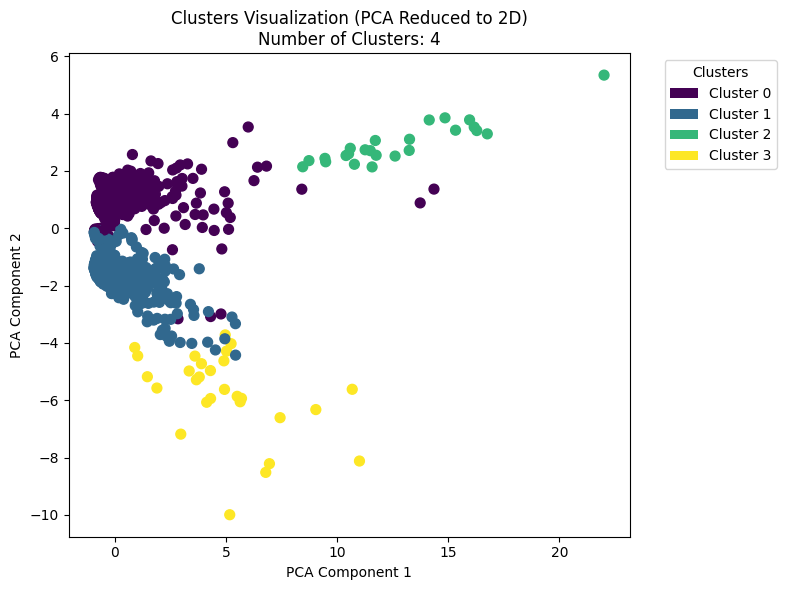

Hierarchical Silhouette Score: 0.2648319927512357


In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(x_standardized.drop(columns='Cluster'))

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(x_standardized.drop(columns='Cluster'), x_standardized['Cluster'])

# Create a scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], c=x_standardized['Cluster'], cmap='viridis', s=50)

# Extract the number of clusters
unique_clusters = np.unique(x_standardized['Cluster'])
num_clusters = len(unique_clusters)

# Add a title with the number of clusters
plt.title(f'Clusters Visualization (PCA Reduced to 2D)\nNumber of Clusters: {num_clusters}')

# Add labels for the axes
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Create a legend for cluster colors
legend_elements = [
    Patch(facecolor=scatter.cmap(scatter.norm(cluster)), label=f'Cluster {cluster}')
    for cluster in unique_clusters
]
plt.legend(handles=legend_elements, title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

print(f"Hierarchical Silhouette Score: {silhouette_avg}")

### Encode step voltage
log transformation first and then do the std deviation

### Supervised Modelling

#### XGBoost

In [36]:
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

def xgboost_classifier(X, y, objective='multi:softmax', learning_rate=0.1, n_estimators=100):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create XGBClassifier with given parameters
    model = XGBClassifier(
        objective=objective,
        learning_rate=learning_rate,
        max_depth=4,
        n_estimators=n_estimators,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    ## Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9530
F1 Score: 0.9524


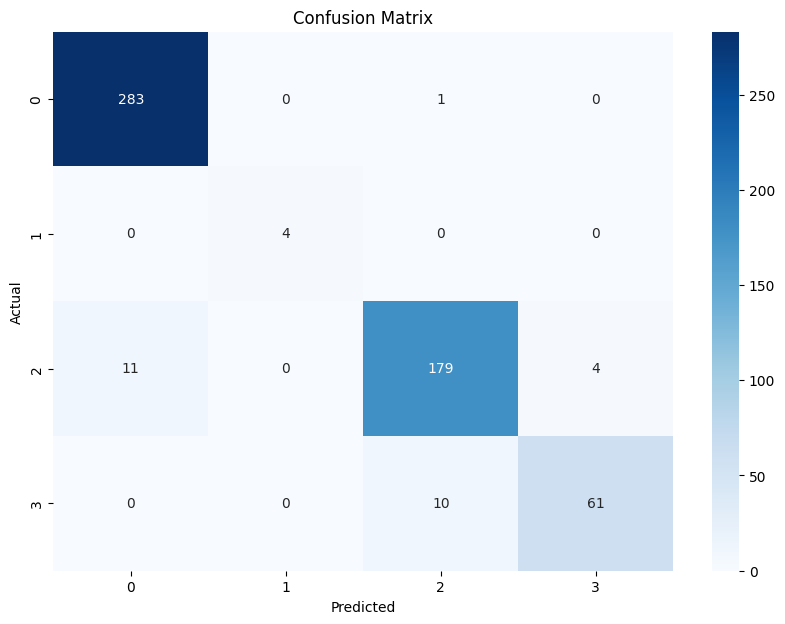

<Figure size 1000x600 with 0 Axes>

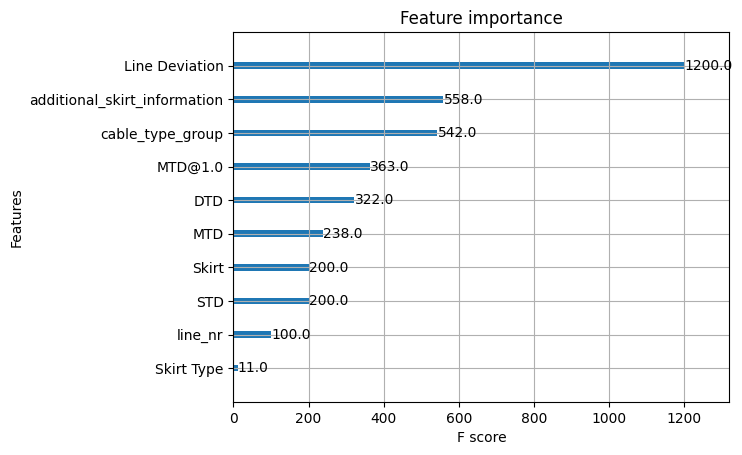

In [37]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = xgboost_classifier(x_standardized, y_adjusted, objective='multi:softmax', learning_rate=0.001, n_estimators=100)

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(model)
plt.show()


### Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_classifier(X, y, n_estimators=100, criterion='gini'):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create RandomForestClassifier with given parameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9873
F1 Score: 0.9874


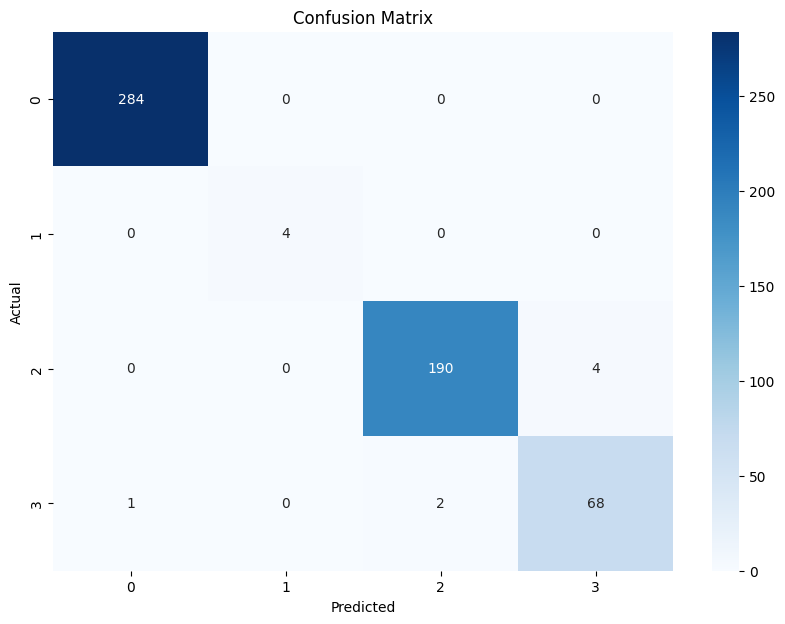

In [39]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = random_forest_classifier(x_standardized, y_adjusted, n_estimators=100, criterion='gini')


                         Feature  Importance
10  additional_skirt_information    0.223402
9                 Line Deviation    0.181504
8                            DTD    0.162387
0               cable_type_group    0.127116
7                        MTD@1.0    0.089424
4                            STD    0.079974
3                            MTD    0.051815
5                          Skirt    0.040521
11                       Cluster    0.019862
6                     Skirt Type    0.013132
2            voltage_step_factor    0.006958
1                        line_nr    0.003904


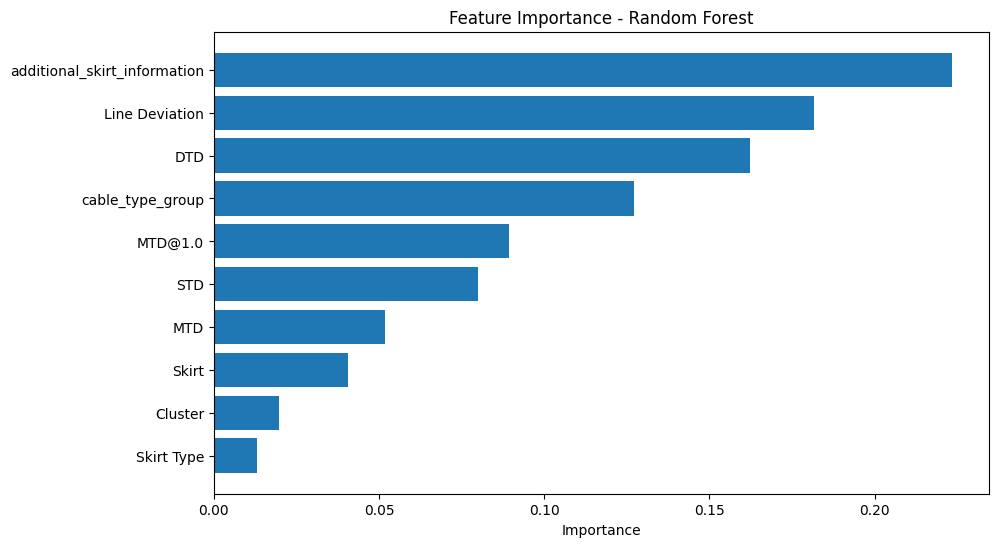

In [40]:
importance_scores = model.feature_importances_
# Create a DataFrame to sort the scores
feature_importance_df = pd.DataFrame({
    'Feature': x_standardized.columns,
    'Importance': importance_scores
})

# Sort the DataFrame by importance
sorted_features = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display sorted feature importance
print(sorted_features)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
plt.barh(sorted_features['Feature'][:10][::-1], sorted_features['Importance'][:10][::-1])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

### KNN 

In [41]:
from sklearn.neighbors import KNeighborsClassifier

def knn_classifier(X, y, n_neighbors=5, metric='minkowski', p=2):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create KNN classifier with given parameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


In [42]:
from sklearn.model_selection import GridSearchCV

def knn_hyperparameter_tuning(X, y):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Define the parameter grid
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    }
    
    # Create a KNN model
    knn = KNeighborsClassifier()
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)
    
    return grid_search.best_estimator_


Accuracy: 0.9204
F1 Score: 0.9182


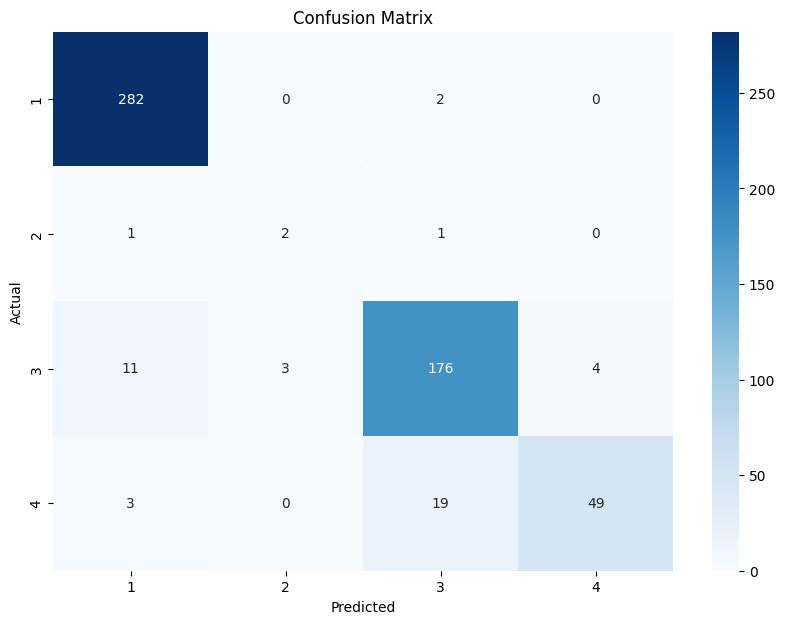

In [43]:
model, acc, f1, cm = knn_classifier(x_standardized, y, n_neighbors=5, metric='minkowski', p=1)

### Progressive Validation

In [44]:
def progressive_validation(model, X, y):
    # Split the dataset into 80% train+validation and 20% test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

    # Define the progressive splits (20%, 40%, 60%, 80%)
    splits = [0.2, 0.4, 0.6, 0.8]
    results = []

    for split in splits:
        # Calculate the number of samples for the current split
        split_size = int(len(X_train_val) * split)

        # Subset the training data
        X_train, y_train = X_train_val[:split_size], y_train_val[:split_size]

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = model.predict(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        # Store the results
        results.append({
            'split': f'{int(split * 100)}% train / 20% test',
            'accuracy': accuracy,
            'f1_score': f1,
            'confusion_matrix': cm
        })

        # Plot the confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"Confusion Matrix for {int(split * 100)}% Train / 20% Test")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # Print results
        print(f"Results for {int(split * 100)}% train / 20% test:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("-" * 40)
    
    return results


KNN Results:


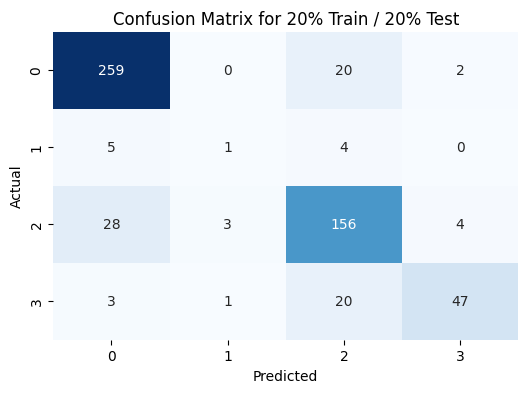

Results for 20% train / 20% test:
Accuracy: 0.8373
F1 Score: 0.8323
----------------------------------------


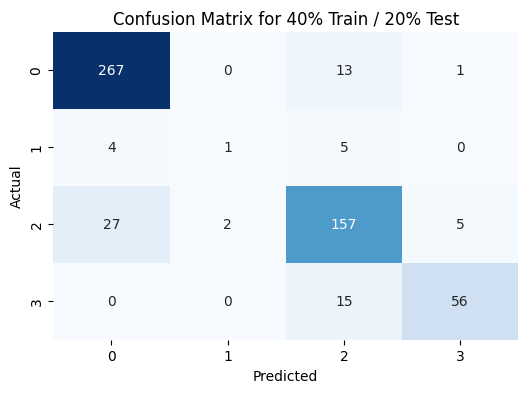

Results for 40% train / 20% test:
Accuracy: 0.8698
F1 Score: 0.8642
----------------------------------------


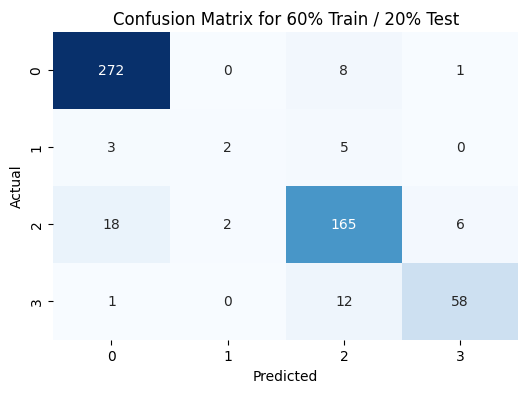

Results for 60% train / 20% test:
Accuracy: 0.8987
F1 Score: 0.8946
----------------------------------------


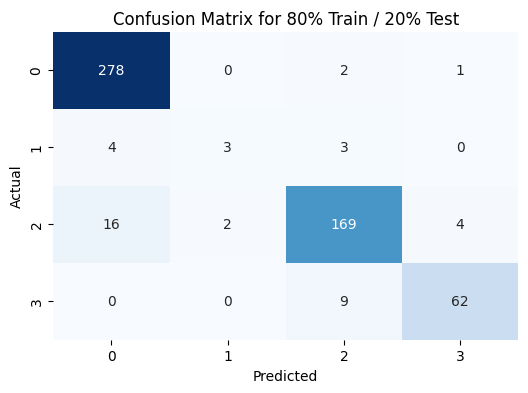

Results for 80% train / 20% test:
Accuracy: 0.9259
F1 Score: 0.9227
----------------------------------------

Random Forest Results:


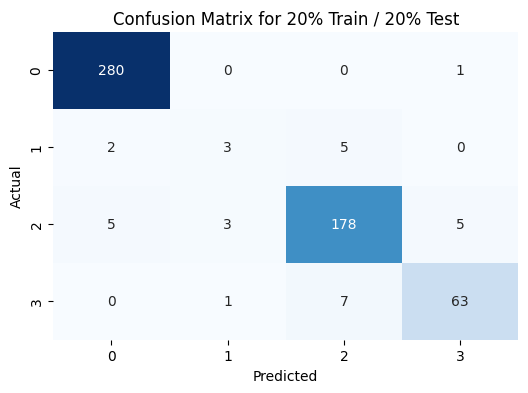

Results for 20% train / 20% test:
Accuracy: 0.9476
F1 Score: 0.9456
----------------------------------------


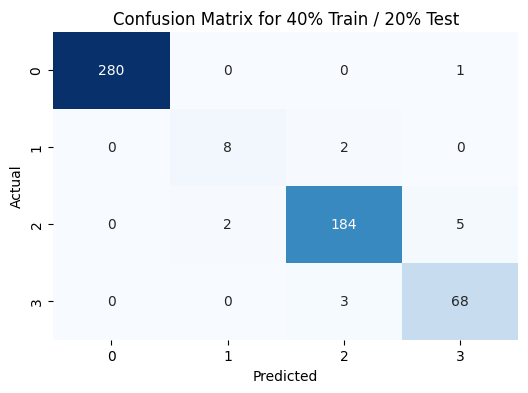

Results for 40% train / 20% test:
Accuracy: 0.9765
F1 Score: 0.9766
----------------------------------------


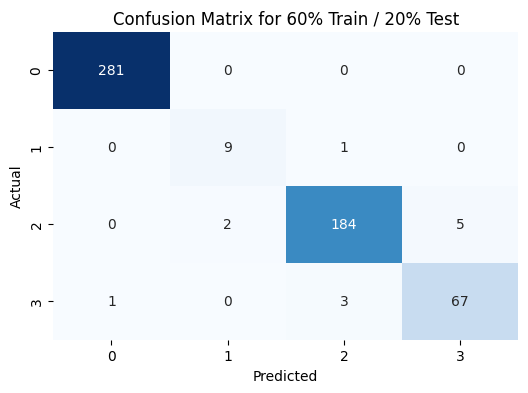

Results for 60% train / 20% test:
Accuracy: 0.9783
F1 Score: 0.9784
----------------------------------------


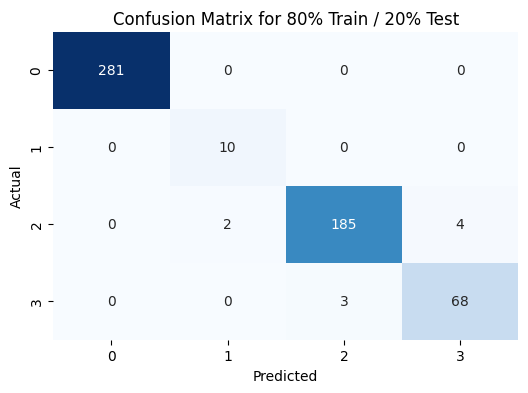

Results for 80% train / 20% test:
Accuracy: 0.9837
F1 Score: 0.9839
----------------------------------------

XGBoost Results:


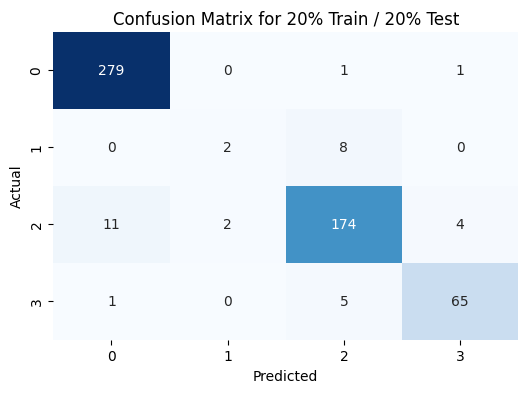

Results for 20% train / 20% test:
Accuracy: 0.9403
F1 Score: 0.9364
----------------------------------------


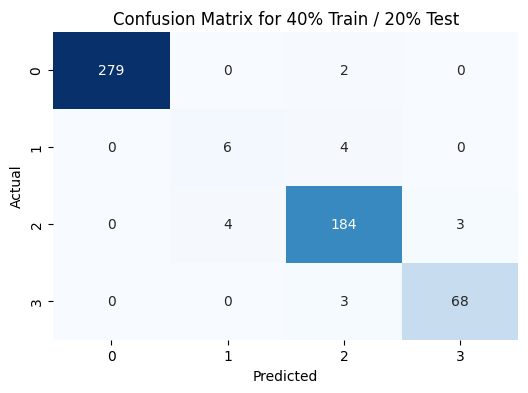

Results for 40% train / 20% test:
Accuracy: 0.9711
F1 Score: 0.9711
----------------------------------------


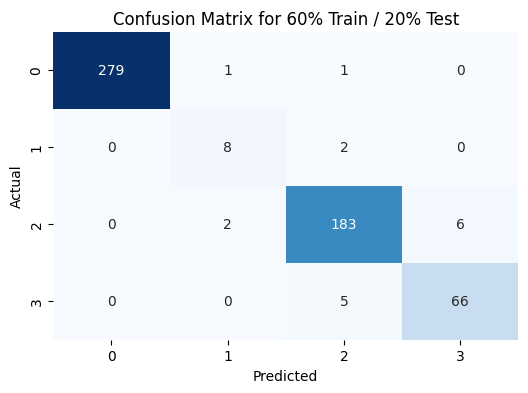

Results for 60% train / 20% test:
Accuracy: 0.9693
F1 Score: 0.9695
----------------------------------------


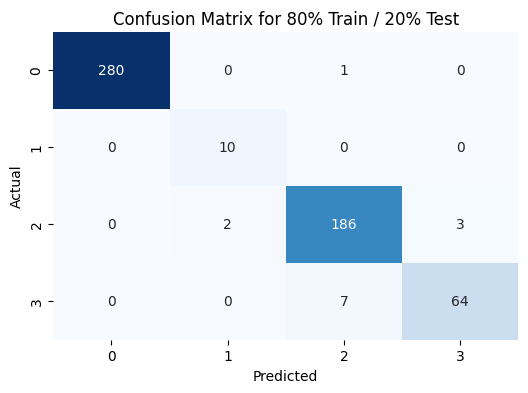

Results for 80% train / 20% test:
Accuracy: 0.9765
F1 Score: 0.9765
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.9403254972875226,
  'f1_score': np.float64(0.93637942512558),
  'confusion_matrix': array([[279,   0,   1,   1],
         [  0,   2,   8,   0],
         [ 11,   2, 174,   4],
         [  1,   0,   5,  65]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.9710669077757685,
  'f1_score': np.float64(0.9711357960905882),
  'confusion_matrix': array([[279,   0,   2,   0],
         [  0,   6,   4,   0],
         [  0,   4, 184,   3],
         [  0,   0,   3,  68]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.969258589511754,
  'f1_score': np.float64(0.9695369579185131),
  'confusion_matrix': array([[279,   1,   1,   0],
         [  0,   8,   2,   0],
         [  0,   2, 183,   6],
         [  0,   0,   5,  66]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.976491862567812,
  'f1_score': np.float64(0.9764841584805232),
  'confusion_matrix': array([[280,   0,   1,   0],
         [  0,  10,   0,   0],
         [  0,   2, 1

In [45]:
# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
print("KNN Results:")
progressive_validation(knn, x_standardized, y)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=20)
print("\nRandom Forest Results:")
progressive_validation(rf, x_standardized, y_adjusted)

# XGBoost Model
xgb = XGBClassifier(objective='multi:softmax', learning_rate=0.001, n_estimators=100, random_state=20)
print("\nXGBoost Results:")
progressive_validation(xgb, x_standardized, y_adjusted)

### Run the model without Additional Skirt Info

KNN Results:


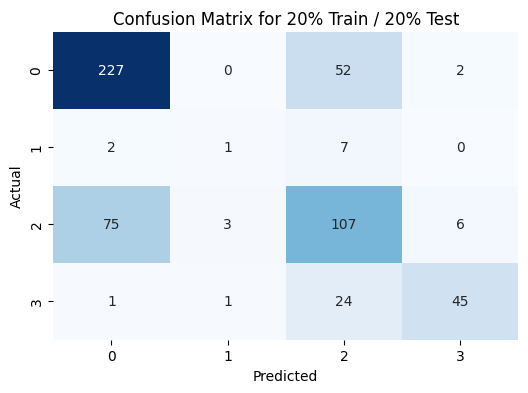

Results for 20% train / 20% test:
Accuracy: 0.6872
F1 Score: 0.6833
----------------------------------------


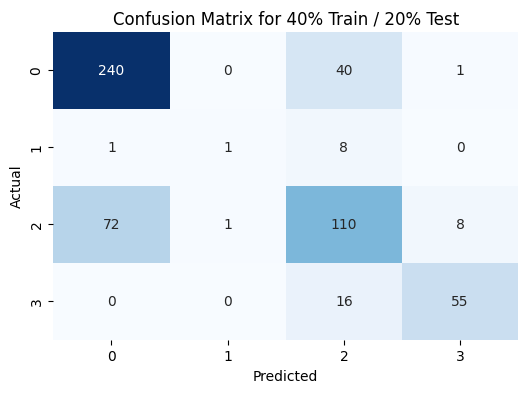

Results for 40% train / 20% test:
Accuracy: 0.7342
F1 Score: 0.7264
----------------------------------------


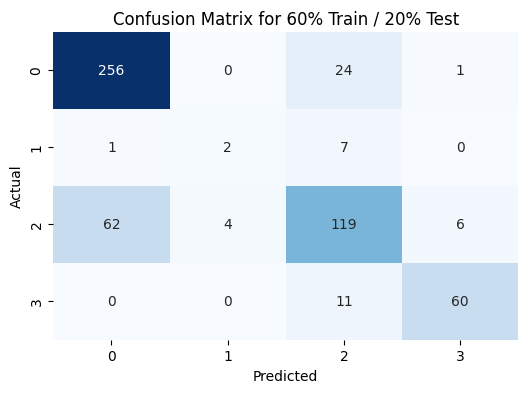

Results for 60% train / 20% test:
Accuracy: 0.7902
F1 Score: 0.7833
----------------------------------------


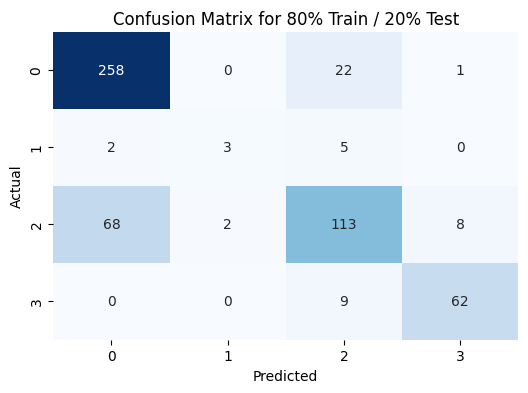

Results for 80% train / 20% test:
Accuracy: 0.7884
F1 Score: 0.7795
----------------------------------------

Random Forest Results:


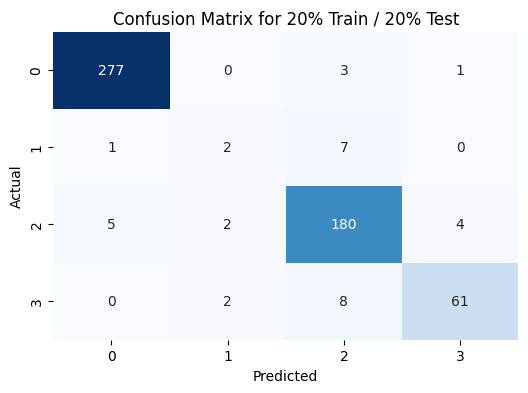

Results for 20% train / 20% test:
Accuracy: 0.9403
F1 Score: 0.9376
----------------------------------------


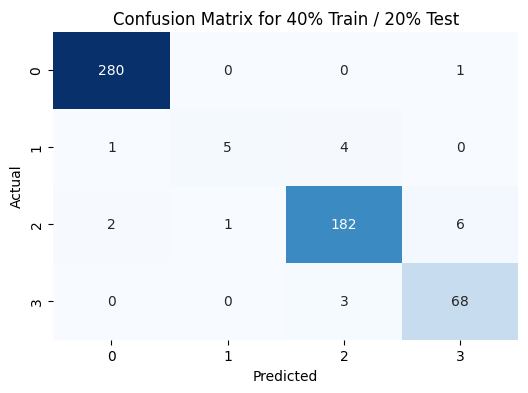

Results for 40% train / 20% test:
Accuracy: 0.9675
F1 Score: 0.9663
----------------------------------------


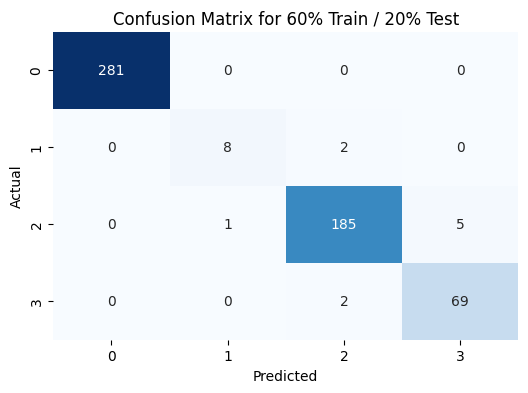

Results for 60% train / 20% test:
Accuracy: 0.9819
F1 Score: 0.9819
----------------------------------------


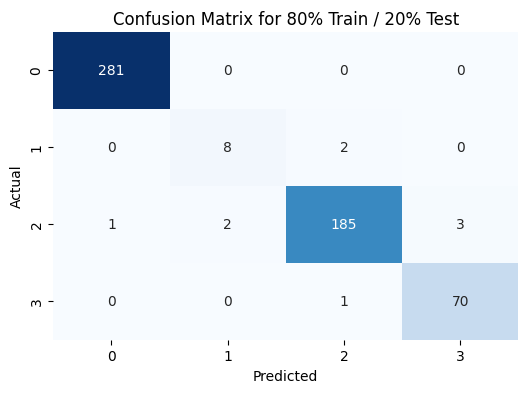

Results for 80% train / 20% test:
Accuracy: 0.9837
F1 Score: 0.9837
----------------------------------------

XGBoost Results:


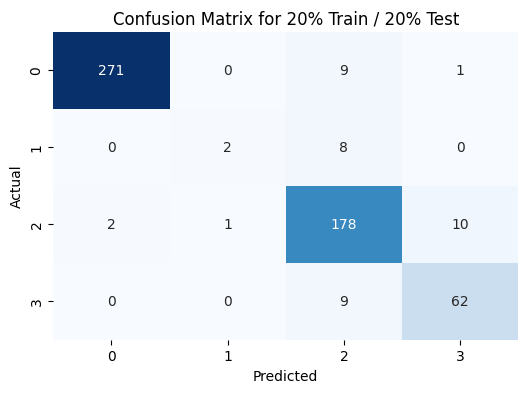

Results for 20% train / 20% test:
Accuracy: 0.9277
F1 Score: 0.9245
----------------------------------------


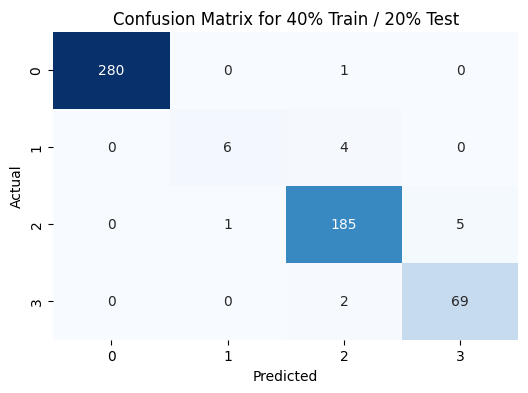

Results for 40% train / 20% test:
Accuracy: 0.9765
F1 Score: 0.9759
----------------------------------------


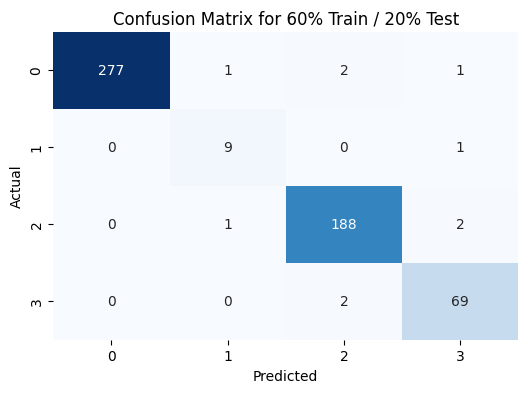

Results for 60% train / 20% test:
Accuracy: 0.9819
F1 Score: 0.9821
----------------------------------------


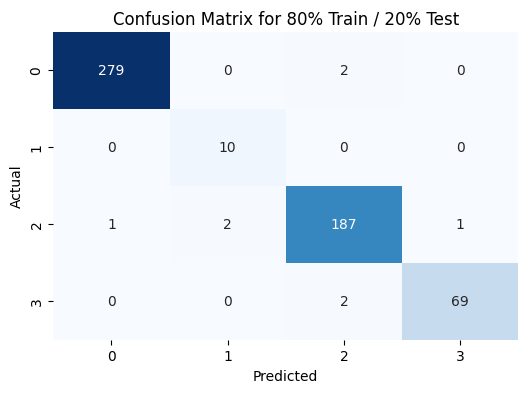

Results for 80% train / 20% test:
Accuracy: 0.9855
F1 Score: 0.9857
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.9276672694394213,
  'f1_score': np.float64(0.9245405814076542),
  'confusion_matrix': array([[271,   0,   9,   1],
         [  0,   2,   8,   0],
         [  2,   1, 178,  10],
         [  0,   0,   9,  62]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.976491862567812,
  'f1_score': np.float64(0.9758541000656263),
  'confusion_matrix': array([[280,   0,   1,   0],
         [  0,   6,   4,   0],
         [  0,   1, 185,   5],
         [  0,   0,   2,  69]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.9819168173598554,
  'f1_score': np.float64(0.9821119289362269),
  'confusion_matrix': array([[277,   1,   2,   1],
         [  0,   9,   0,   1],
         [  0,   1, 188,   2],
         [  0,   0,   2,  69]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.9855334538878843,
  'f1_score': np.float64(0.9856737739534271),
  'confusion_matrix': array([[279,   0,   2,   0],
         [  0,  10,   0,   0],
         [  1,   2

In [46]:
x_standardized = x_standardized.drop(['additional_skirt_information'],axis=1)
# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
print("KNN Results:")
progressive_validation(knn, x_standardized, y)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=20)
print("\nRandom Forest Results:")
progressive_validation(rf, x_standardized, y_adjusted)

# XGBoost Model
xgb = XGBClassifier(objective='multi:softmax', learning_rate=0.001, n_estimators=100, random_state=20)
print("\nXGBoost Results:")
progressive_validation(xgb, x_standardized, y_adjusted)